# Ghana Cloud Cover Data Analysis (Sentinel-2, 2024)

This notebook investigates the temporal variation in cloud cover over Ghana using Sentinel-2 Level-2A imagery for the year 2024. Data is retrieved from the Earth Search STAC API, filtered spatially to Ghana’s national boundaries, and analysed on a monthly basis.

The aims of this analysis are:

1. To retrieve cloud-cover metadata from a STAC-compliant data catalogue
2. To examine monthly trends in cloud cover
3. To identify the best time of year for optical satellite image acquisition
4. To demonstrate good practice in reusable, modular scientific Python code


In [ ]:
# --- Imports ---
# Standard scientific stack for data analysis and visualization
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import folium

# Local helper function for STAC API queries
from ghana_cloud_stac import build_search_payload, stac_search, parse_items_to_df

## 1. Study Area: Ghana

Ghana is located in West Africa and experiences two dominant climatic phases:
a dry season (roughly November–February) and a wet monsoon season (June–September).
Persistent cloudiness during the rainy season can strongly limit the usability
of optical satellite imagery.

The map below shows the **bounding box** used to spatially constrain all
STAC queries in this analysis.


In [ ]:
# --- Define Ghana bounding box ---
# Bounding box chosen to cover Ghana's national territory
bbox = [-3.0907, 4.5350, 0.9371, 11.1279]
center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2

# --- Folium Map ---
# Interactive map to confirm spatial extent of analysis
m = folium.Map(location=[center_lat, center_lon], zoom_start=6)
folium.Rectangle(
    bounds=[[bbox[1], bbox[0]], [bbox[3], bbox[2]]],
    color="blue", fill=True, fill_opacity=0.2
).add_to(m)
m

## 2. Data Source and Query Method

Satellite metadata is retrieved from the Earth Search STAC API,
which provides access to a large catalogue of publicly available Earth observation data.

Key parameters used:
- **Collection**: `sentinel-2-l2a`
- **Year**: 2024
- **Region**: Ghana (defined by bounding box)
- **Property used**: `eo:cloud_cover`
- **Limit**: 300 scenes per month

Each month of 2024 is queried individually in order to examine temporal variation.  
The query returns STAC item metadata, which is converted into a Pandas DataFrame
for analysis.


In [ ]:
# --- STAC Search Parameters ---
# Sentinel-2 Level 2A provides atmospherically corrected reflectance data
collection = "sentinel-2-l2a"
year = 2024
limit = 300  # sampling cap per month to keep queries manageable

# --- Data Acquisition ---
all_dfs = []
for month in range(1, 13):
    # Build ISO8601 datetime range for each month
    start = f"{year}-{month:02d}-01T00:00:00Z"
    end = f"{year}-{month+1:02d}-01T00:00:00Z" if month < 12 else f"{year}-12-31T23:59:59Z"
    datetime_range = f"{start}/{end}"

    # Create and execute STAC API search request
    payload = build_search_payload(collection, bbox, datetime_range, limit=limit)
    response = stac_search(payload)
    items = response.get("features", [])

    # Convert STAC items to DataFrame and process timestamps
    df_month = parse_items_to_df(items)
    df_month["datetime"] = pd.to_datetime(df_month["datetime"], utc=True)
    df_month["year_month"] = df_month["datetime"].dt.strftime("%Y-%m")
    all_dfs.append(df_month)

# Combine all monthly data into a single DataFrame
df = pd.concat(all_dfs, ignore_index=True)
df


,id,datetime,cloud_cover,year_month
0,S2A_30NVL_20240131_0_L2A,2024-01-31 10:39:47.475000+00:00,4.254335,2024-01
1,S2A_30NWL_20240131_0_L2A,2024-01-31 10:39:42.538000+00:00,14.750876,2024-01
2,S2A_30NXL_20240131_0_L2A,2024-01-31 10:39:39.441000+00:00,5.135116,2024-01
3,S2A_30NYL_20240131_0_L2A,2024-01-31 10:39:35.738000+00:00,0.494206,2024-01
4,S2A_30NWM_20240131_0_L2A,2024-01-31 10:39:27.966000+00:00,25.383490,2024-01
...,...,...,...,...
3595,S2B_30NWL_20241211_0_L2A,2024-12-11 10:39:48.201000+00:00,21.652725,2024-12
3596,S2B_30NXL_20241211_0_L2A,2024-12-11 10:39:45.133000+00:00,23.314090,2024-12
3597,S2B_30NYL_20241211_0_L2A,2024-12-11 10:39:41.429000+00:00,15.596616,2024-12
3598,S2B_30NWM_20241211_0_L2A,2024-12-11 10:39:33.646000+00:00,33.561650,2024-12


## 3. Raw Data Overview

The resulting DataFrame contains:
- Scene ID
- Acquisition datetime (UTC)
- Cloud cover percentage (%)
- Year–month label

This DataFrame contains 3600 rows, representing satellite scenes
covering Ghana in 2024.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id           3600 non-null   object             
 1   datetime     3600 non-null   datetime64[ns, UTC]
 2   cloud_cover  3600 non-null   float64            
 3   year_month   3600 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 112.6+ KB


In [ ]:
df.describe()

,cloud_cover
count,3600.000000
mean,49.815153
std,38.097130
min,0.000000
25%,10.244411
50%,48.620452
75%,90.352145
max,100.000000


## 4. Data Cleaning and Outlier Removal

Before aggregation, the cloud-cover values are cleaned:

- Non-numeric values are coerced to NaN
- Month labels are extracted from the datetime
- The Interquartile Range (IQR) method is applied per month
  to remove extreme values that may represent sensor errors or rare
  atmospheric anomalies (e.g., dust storms)

This ensures that monthly averages are not biased by isolated extremes.


In [ ]:
# --- Data Cleaning ---

# Convert cloud_cover column to numeric values, setting invalid entries to NaN
df["cloud_cover"] = pd.to_numeric(df["cloud_cover"], errors="coerce")

# Extract month name abbreviation from the datetime column
df["month_name"] = df["datetime"].dt.month.apply(lambda m: calendar.month_abbr[m])

# --- Outlier Removal Function ---
def remove_outliers_iqr(df, column="cloud_cover", group="month_name"):
    """
    Removes extreme values using the IQR rule.
    This ensures monthly averages are not skewed by rare sensor occurrences
    or unusual atmospheric conditions (e.g., dust storms).
    """
    # Create a copy of the dataframe to avoid modifying the original
    df_clean = df.copy()

    # Process each unique group (e.g., each month) separately
    for g in df_clean[group].unique():
        subset = df_clean[df_clean[group] == g][column].dropna()
        Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        # Filter out rows that contain outliers in the current group
        df_clean = df_clean[~((df_clean[group] == g) &
                              ((df_clean[column] < lower) | (df_clean[column] > upper)))]
    return df_clean

# Apply the outlier removal function to the dataframe
df_no_outliers = remove_outliers_iqr(df)



In [ ]:
# --- Monthly Average Cloud Cover ---
monthly_avg = df_no_outliers.groupby("year_month")["cloud_cover"].mean().reset_index()

# Add a new column with abbreviated month names (e.g., Jan, Feb) for better readability in visualisations
monthly_avg["month_name"] = pd.to_datetime(monthly_avg["year_month"]).dt.month.apply(lambda m: calendar.month_abbr[m])



## 5. Outlier Exploration

The boxplot below visualises the distribution of cloud cover values
for each month, highlighting both variability and extreme values.

This allows a visual comparison of:
- Months with high typical cloud cover
- Months with high variability
- Overall seasonal progression


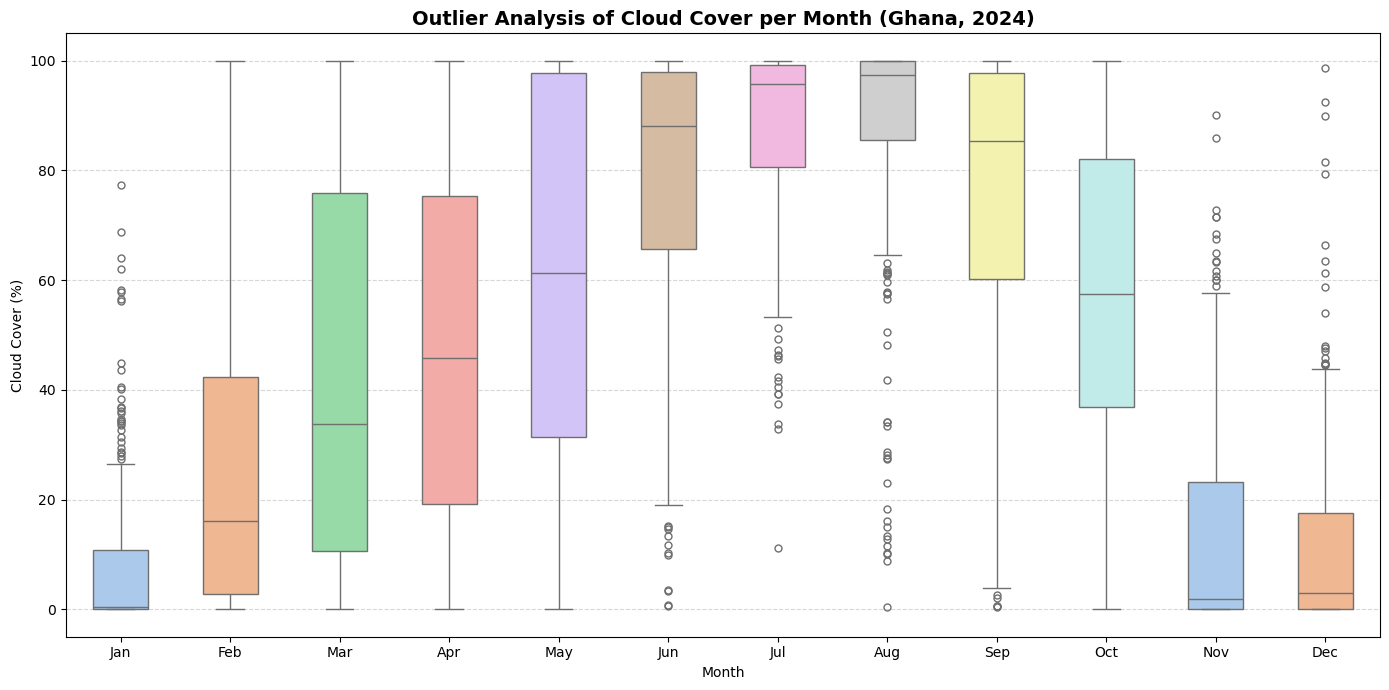

In [ ]:
# --- Visualization 1: Boxplot Outliers ---
plt.figure(figsize=(14,7))
sns.boxplot(x="month_name", y="cloud_cover", data=df, palette="pastel", hue="month_name", width=0.5, fliersize=5)
plt.title("Outlier Analysis of Cloud Cover per Month (Ghana, 2024)", fontsize=14, weight="bold")
plt.xlabel("Month"); plt.ylabel("Cloud Cover (%)")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout(); plt.show()



## 6. Monthly Mean Cloud Cover

The line plot below shows the mean cloud cover (%) for each month
after outliers have been removed.

A clear seasonal pattern can be observed across 2024.


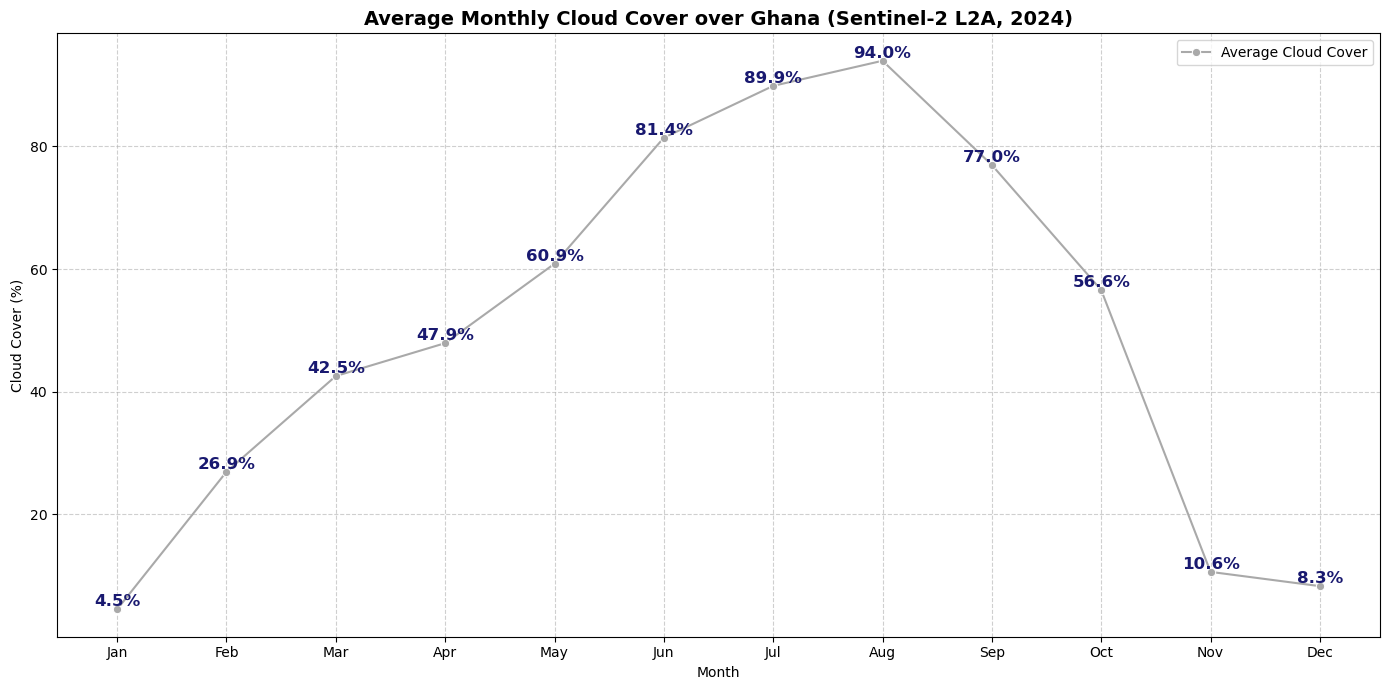

In [ ]:
# --- Visualization 2: Line Plot Monthly Average ---
plt.figure(figsize=(14,7))
sns.lineplot(data=monthly_avg, x="month_name", y="cloud_cover", marker="o", color="darkgrey", label="Average Cloud Cover")
for i, row in monthly_avg.iterrows():
    plt.text(row["month_name"], row["cloud_cover"], f"{row['cloud_cover']:.1f}%",
             ha="center", va="bottom", fontsize=12, color="midnightblue", weight="bold")
plt.title("Average Monthly Cloud Cover over Ghana (Sentinel-2 L2A, 2024)", fontsize=14, weight="bold")
plt.xlabel("Month"); plt.ylabel("Cloud Cover (%)")
plt.grid(True, linestyle="--", alpha=0.6); plt.legend(loc="upper right")
plt.tight_layout(); plt.show()



## 7. Visual Summary of Monthly Conditions

A colour‐graded bar plot is used to emphasise:
- Low cloud cover (lighter colours)
- High cloud cover (darker greys)
- The progression from dry to wet season

This plot is included as the portfolio figure due to its clarity
and aesthetic presentation.


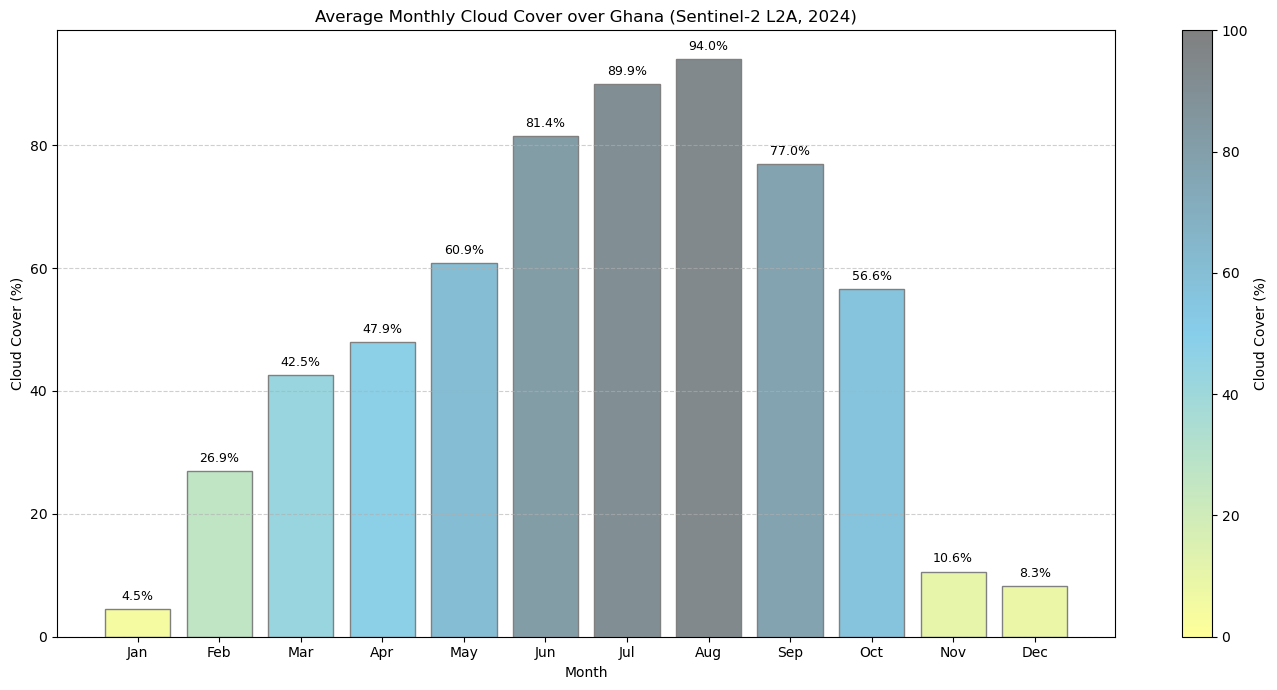

In [ ]:
# --- Visualization 3: Gradient Bar Plot ---
cmap = mcolors.LinearSegmentedColormap.from_list("cloud_cover_cmap", ["#FFFF99", "#87CEEB", "#808080"])
norm = mcolors.Normalize(vmin=0, vmax=100)

fig, ax = plt.subplots(figsize=(14,7))
bars = ax.bar(monthly_avg["month_name"], monthly_avg["cloud_cover"], edgecolor="grey")
for bar, value in zip(bars, monthly_avg["cloud_cover"]):
    bar.set_facecolor(cmap(norm(value)))
    ax.text(bar.get_x() + bar.get_width()/2, value + 1, f"{value:.1f}%", ha="center", va="bottom", fontsize=9, color="black")

ax.set_title("Average Monthly Cloud Cover over Ghana (Sentinel-2 L2A, 2024)")
ax.set_xlabel("Month"); ax.set_ylabel("Cloud Cover (%)")
ax.grid(True, linestyle="--", alpha=0.6, axis="y")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, label="Cloud Cover (%)")
plt.tight_layout(); plt.show()

## 8. Summary and Recommendation

Figure above displays the average monthly cloud cover over Ghana
based on Sentinel-2 Level-2A satellite data for the year 2024.

The analysis highlights a strong seasonal cycle driven by regional
climate patterns, particularly the West African monsoon with outliers from November to December due to phenomenons such as dust storms.


## Conclusion

- **Recommended best period for optical image acquisition:**
- **November – February**

Using Sentinel-2 Level-2A imagery for 2024, both the number of available scenes and the mean percentage cloud cover over Ghana for each month are examined. Image availability is fairly consistent through the year, but cloudiness shows a strong seasonal pattern. Mean cloud cover is lowest during boreal winter from November to January. The highest cloud fractions occur between June and September, when mean values exceed 70–80%. This monsoon period when cloud cover is at its highest.

For optical satellite imaging that requires a high probability of cloud-free or lightly obscured scenes, the best time for image collection over Ghana is therefore the dry-season window from November to February. Acquisitions in this period maximise the chance of usable imagery while still providing sufficient temporal coverage. Conversely, planning image-capture during June–September would be inefficient, as a large proportion of images are likely to be unusable due to extensive cloud cover.

## References

Lutz, M. (2023). *Learning Python* (6th ed.). O’Reilly Media.

SpatioTemporal Asset Catalog (STAC) Specification. (n.d.). *STAC – SpatioTemporal Asset Catalog*. https://stacspec.org/

Python Software Foundation. (n.d.). *PEP 8 – Style Guide for Python Code*. https://peps.python.org/pep-0008/

Microsoft. (2023). *GitHub Copilot* [AI-powered code completion tool]. https://github.com/features/copilot

GeoJason. (n.d.). *GeoJason GeoJSON utility for geographic bounding boxes*. https://geojson.io/

